# Generating temperature timeseries over Brazil using Python

> In this tutorial we learn...
>
> #### Objectives
> - Understand how downscaling allows more precise results
> - Use exact extract for generating the population weighted temperature timeseries in Salvador
> - Plot the nat and hist-nat results for the climatology
>
> #### Inputs
> - IGR shapefiles
> - DAMIP temperature 2D data
> - Worldpop population data
>
> #### Outputs

In [1]:
# Task

# 1. compare DAMIP raw to downscaled for regions in Salvador

# 2. compare hist to hist nat for downscaled data in Salvador 

# 3. choose region of choice for something else

In [2]:
# link = 'https://fiocruzbr-my.sharepoint.com/:u:/g/personal/taisa_cortes_fiocruz_br/IQC3_oBBith0TojO0uytGejTAcpYWCNB7Jxh4n7hOgIJWog?e=q2nZd4'

In [3]:
# Emily
# TODO: set up colab
# TODO: upload all shapefiles to google drive
# TODO: upload all other relevant files to google drive


### 0. Imports

In [ ]:
import gdown
!pip install exactextract
!pip install rioxarray
!pip install cartopy
gdown.download(
    "https://raw.githubusercontent.com/vosps/attribution_tutorial/main/timeseries_functions.py",
    "timeseries_functions.py",
    quiet=True
)

In [27]:
# import python packages
import xarray as xr
import pandas as pd
import xarray as xr
import h5py
import numpy as np
import matplotlib.pyplot as plt
from exactextract import exact_extract
import geopandas as gpd
import rioxarray
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from timeseries_functions import process_data,plot_timeseries,plot_climatology,plot_region



### 1. Download and load data

In [ ]:
gdown.download(
    "https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N",
    "CanESM5_historical_temperature_original_resolution.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N",
    "observed_temperature.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1K7C5CYAAef8r0qkAJyAK_wyNAowrhUiY",
    "histnat_downscaled.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1dXc1V5WcIR3ER_KrE4DyJR3kH7ggD2Dk",
    "historical_downscaled.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1YWXAQQxeL-OqNdRxeyyiBnQQ7B3Gq8nv",
    "pop_density_28deg.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=13pLPN66EIpf-RUmQdzP2Iui0jHzJnbbx",
    "population_density_05deg.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1Gfd0ApuQRto9How2wWMvrZ7TKSAbDKJF",
    "temperature_observations.nc",
    quiet=False
)

gdown.download(
    "https://drive.google.com/uc?id=1TvF-32rf60nlcTFhe9Txlc4J1aovjwsa",
    "shapefile.parquet",
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N
From (redirected): https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N&confirm=t&uuid=f12c9956-f75a-4234-b032-97fe04e3820d
To: /Users/al18709/Documents/coding_tutorials/attribution_tutorial/CanESM5_historical_temperature_original_resolution.nc
100%|██████████| 228M/228M [01:34<00:00, 2.41MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N
From (redirected): https://drive.google.com/uc?id=1hVF3ML6ezgz6fln31dGpHcJOdu4FBP-N&confirm=t&uuid=938b734f-b05e-4d9c-bd85-d657b00b35b3
To: /Users/al18709/Documents/coding_tutorials/attribution_tutorial/observed_temperature.nc
100%|██████████| 228M/228M [00:56<00:00, 4.02MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1K7C5CYAAef8r0qkAJyAK_wyNAowrhUiY
From (redirected): https://drive.google.com/uc?id=1K7C5CYAAef8r0qkAJyAK_wyNAowrhUiY&confirm=t&uuid=32f8c0c9-b4ee-4f3d-b18

'temperature_observations.nc'

In [45]:
# open datasets
# TODO: check if engine should be changed to hdf5

############################
# load temperature datasets
############################

# original resolution historical climate
# original = xr.open_dataset("tas_CanESM5_historical_r1i1p1f1_v20190429_2000-2018.nc", engine="netcdf4")
# # downscaled equivalent
# historical = xr.open_dataset("historical_downscaled_no_mask.nc", engine="netcdf4")
# natural = xr.open_dataset("hist_nat_downscaled_no_mask.nc", engine="netcdf4")
# # observational dataset
# observations = xr.open_dataset("obs_05x05_2000_2018_padded_interp_for_tutorial.nc", engine="netcdf4")

# # population density data
# pop_density = xr.open_dataarray("population_density_05deg_demo.nc").isel(lon=slice(0,82))
# pop_density_original_resolution = xr.open_dataarray("population_density_original+resolution_deg_demo.nc")

# # municipality shapefile
shapefile = gpd.read_file("shapefile_data/RG2017_rgi.shp")

# original resolution historical climate
original = xr.open_dataset("CanESM5_historical_temperature_original_resolution.nc", engine="netcdf4")
# downscaled equivalent
historical = xr.open_dataset("historical_downscaled.nc", engine="netcdf4")
natural = xr.open_dataset("histnat_downscaled.nc", engine="netcdf4")
# observational dataset
observations = xr.open_dataset("temperature_observations.nc", engine="netcdf4")

# population density data
pop_density = xr.open_dataarray("population_density_05deg.nc",engine="netcdf4").isel(lon=slice(0,82))
pop_density_original_resolution = xr.open_dataarray("pop_density_28deg.nc",engine="netcdf4")

# municipality shapefile
shapefile = gpd.read_parquet("shapefile.parquet")



##############################################
# process the data into the appropriate format
##############################################

historical,natural,observations,original,pop_density,pop_density_original_resolution = process_data(historical,natural,observations,original,pop_density,pop_density_original_resolution)

# Set index for exactextract
# rgi_indexed = shapefile.set_index("rgi")

# get shapefile for Salvador
salvador = shapefile[shapefile['nome_rgi'] == 'Salvador']




### 2. Plot Salvador

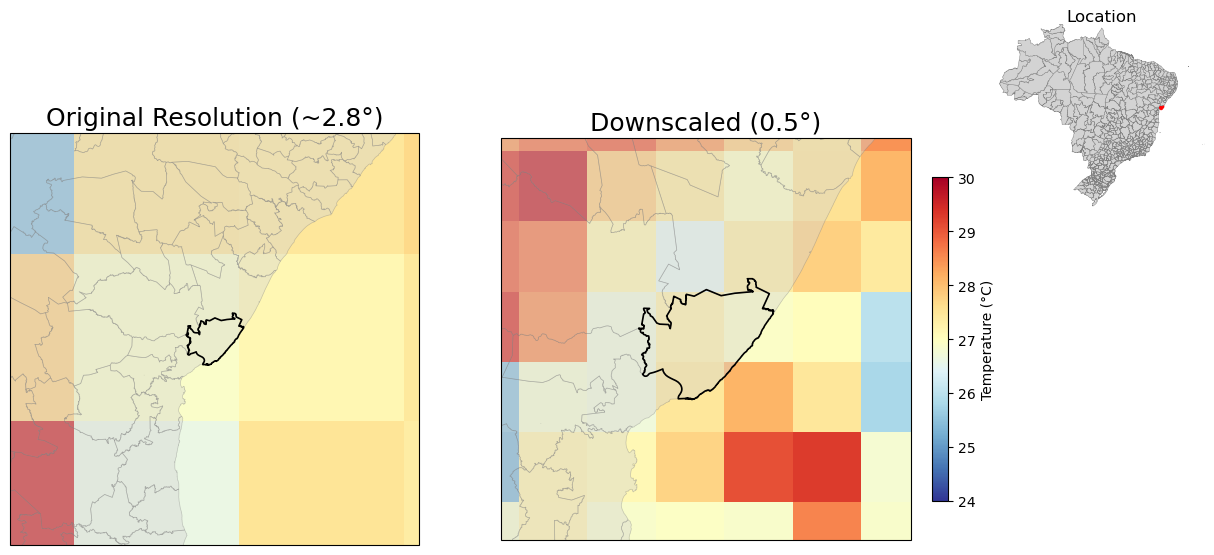

In [ ]:
plot_region('Salvador',shapefile, original, historical)


In [ ]:
# TODO: make an anomaly plot and make colourbar discrete. could include values
# TODO: add title making it clear its bias correction and downscaling.
# TODO: add non bias correction in the middle to show what the bias correction step does. 
# TODO: don't need point data we just need region

### 2. Plot population data at same resolution as temperature data

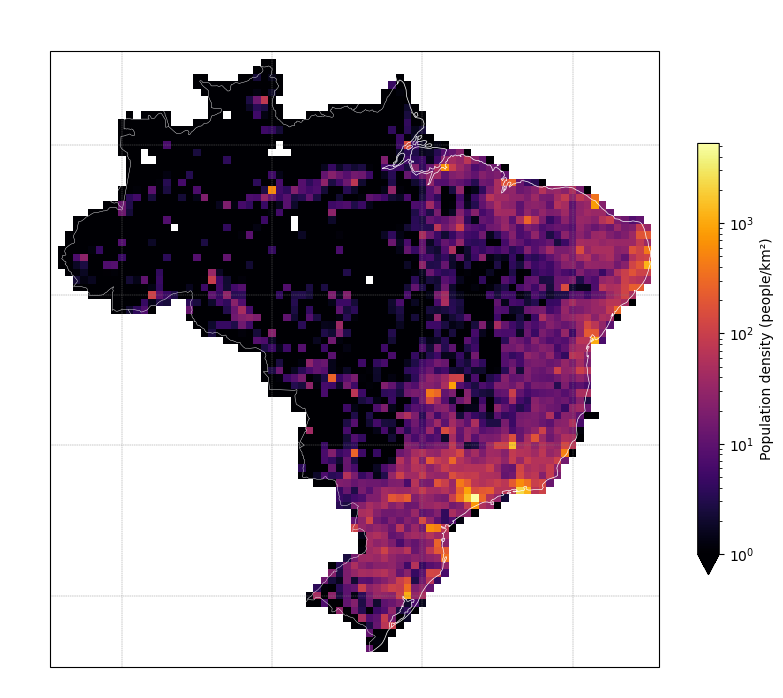

In [ ]:
# plot population density data

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

pop_density.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    norm=LogNorm(vmin=1, vmax=float(pop_density.max())),
    cmap='inferno',
    cbar_kwargs={'label': 'Population density (people/km²)', 'shrink': 0.7}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='white')
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.3, edgecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--', color='gray')
gl.xlabel_style = {'color': 'white'}
gl.ylabel_style = {'color': 'white'}

ax.set_title('Population Density', color='white')
plt.show()


### 3. Process the timeseries using exact extract
>
> - exact extract works by doing a weighted mean of grid cells that appear within a shapefile
> - exact extract calculates the area of the grid cells inside each shapefile polygon
> - the result depends on how the shapefile intersects with each grid cell, e.g. in the image below, only the area highlighted in pink is included in the mean calculation.

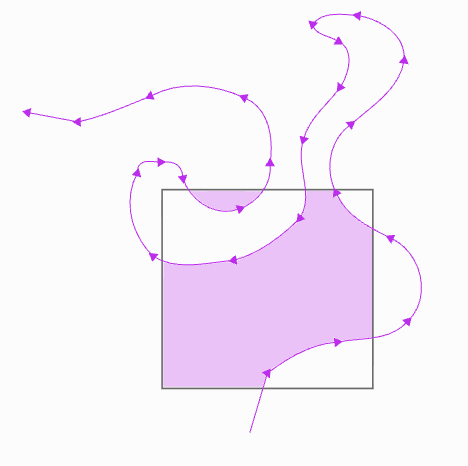


In [ ]:
def process_time_step(i,downscaled, times, time_period,rgi='Salvador',rgi_indexed=rgi_indexed,pop_density=pop_density):
    """
    Extract the population-weighted mean daily temperature for a given region
    at a given time step.

    Parameters
    ----------
    i : int
        Index of the time step to process.
    rgi : str, optional
        Name of the region of interest (matched against the 'nome_rgi' column).
        Defaults to 'Salvador'.
    times : array-like
        Array of time values corresponding to the downscaled dataset.
    rgi_indexed : GeoDataFrame
        Shapefile GeoDataFrame indexed by 'rgi' code.
    downscaled : xr.Dataset
        Downscaled temperature dataset with dimensions (time, lat, lon).
    pop_density : xr.DataArray
        Population density raster used as weights.

    Returns
    -------
    float
        Population-weighted mean temperature for the specified region
        at time step i.
    """
    # date = str(times[i])
    print(f"Processing time step {i+1}/{len(time_period)}", end='\r', flush=True)

    # Rename coordinates
    downscaled_i = downscaled.isel(time=i).rename({"lat": "y", "lon": "x"})
    pop_renamed = pop_density.rename({"lat": "y", "lon": "x"})
    
    # select rgi of interest
    rgi_of_interest = rgi_indexed[rgi_indexed.nome_rgi == rgi]

    # Extract both unweighted and weighted means
    df = exact_extract(
        downscaled_i,
        rgi_of_interest,
        ['mean(coverage_weight=area_spherical_m2)', 'weighted_mean(coverage_weight=area_spherical_m2)'],
        weights=pop_renamed,
        output='pandas'
    )
    
    return df['weighted_mean'].values[0]


In [ ]:
times = historical.time
# select period between two dates
time_period = times.sel(time=slice('2016-01-01', '2018-01-01'))
# get the integer indices of time_period within the full times array
time_indices = [int(np.where(times == t)[0][0]) for t in time_period]

# original resolution timeseries for comparison
salvador_timeseries_original = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, original, times, time_period, rgi='Salvador', pop_density=pop_density_original_resolution) for i in time_indices]
}, index=time_period)

In [ ]:
# historical timeseries
salvador_timeseries_historical = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, historical, times, time_period,rgi='Salvador') for i in time_indices]
}, index=time_period)




In [ ]:
# reassign coordinates to match historical
# natural = natural.assign_coords(
#     time=historical.time,
#     lat=historical.lat,
#     lon=historical.lon
# )
natural


<xarray.Dataset> Size: 373MB
Dimensions:      (lat: 82, lon: 82, time: 6940)
Coordinates:
  * lat          (lat) float64 656B -34.5 -34.0 -33.5 -33.0 ... 4.5 5.0 5.5 6.0
  * lon          (lon) float64 656B -74.5 -74.0 -73.5 ... -35.0 -34.5 -34.0
  * time         (time) datetime64[ns] 56kB 2000-01-01 2000-01-02 ... 2018-12-31
    spatial_ref  int64 8B 0
Data variables:
    tas          (lat, lon, time) float64 373MB ...

In [ ]:
# natural timeseries
salvador_timeseries_natural = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, natural, times, time_period, rgi='Salvador') for i in time_indices]
}, index=time_period)

In [ ]:
# observational timeseries for comparison
salvador_timeseries_observations = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, observations, times, time_period,rgi='Salvador') for i in time_indices]
}, index=time_period)


### 4. Plot the timeseries

/Users/al18709/Documents/coding_tutorials/attribution_tutorial/timeseries_functions.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


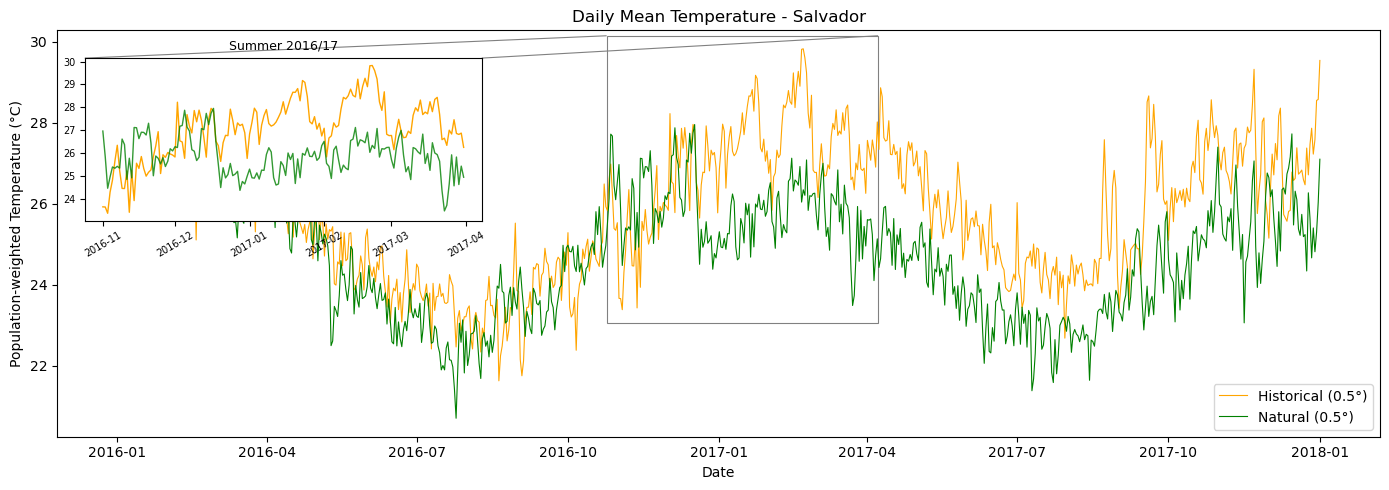

In [ ]:
plot_timeseries(salvador_timeseries_historical, salvador_timeseries_natural)


### 5. Plot the climatology

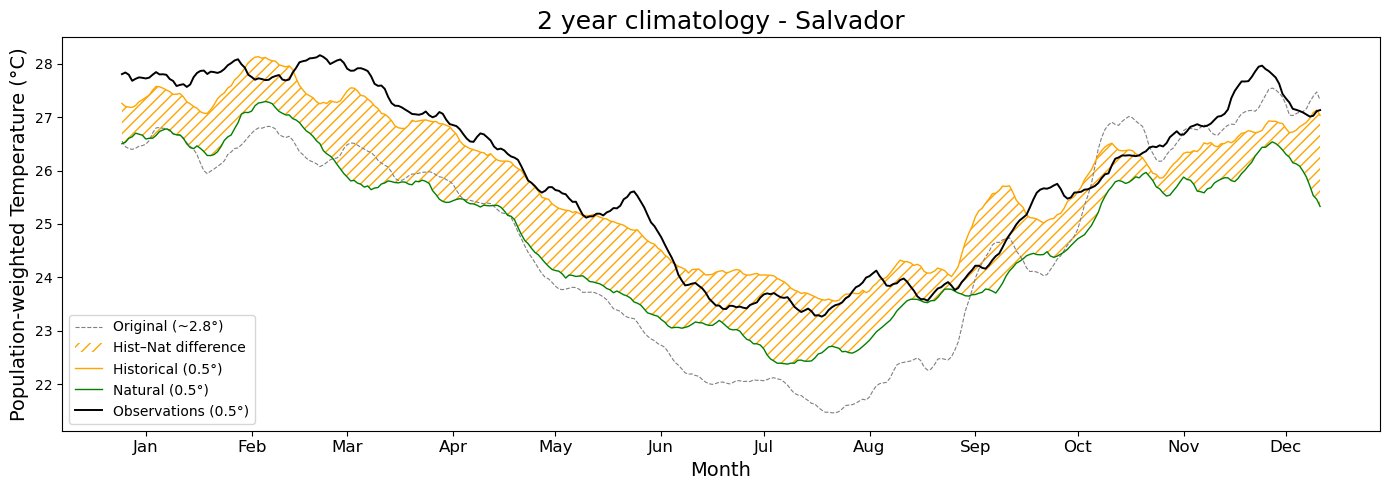

In [ ]:
plot_climatology(
    salvador_timeseries_historical,
    salvador_timeseries_natural,
    salvador_timeseries_observations,
    timeseries_original=salvador_timeseries_original,
    title='2 year climatology - Salvador'
)


## Exercise: compare downscaled timeseries between nat and hist nat for a region of your choice
>
> #### Change the lines of code where it says "#TODO:"

In [30]:
# regions you can choose
shapefile['nome_rgi'].unique()

<StringArray>
[               'Porto Velho',                  'Ariquemes',
                       'Jaru',                  'Ji-Paraná',
                     'Cacoal',                    'Vilhena',
                 'Rio Branco',                  'Brasiléia',
             'Sena Madureira',            'Cruzeiro do Sul',
 ...
                      'Iporá',         'Palmeiras de Goiás',
                  'Porangatu',       'Uruaçu - Niquelândia',
 'Ceres - Rialma - Goianésia',                   'Luziânia',
      'Águas Lindas de Goiás',         'Posse-Campos Belos',
            'Flores de Goiás',           'Distrito Federal']
Length: 508, dtype: str

In [31]:
region_name = 'Luziânia' # TODO: change to other region of interest
my_region = shapefile[shapefile['nome_rgi'] == region_name]

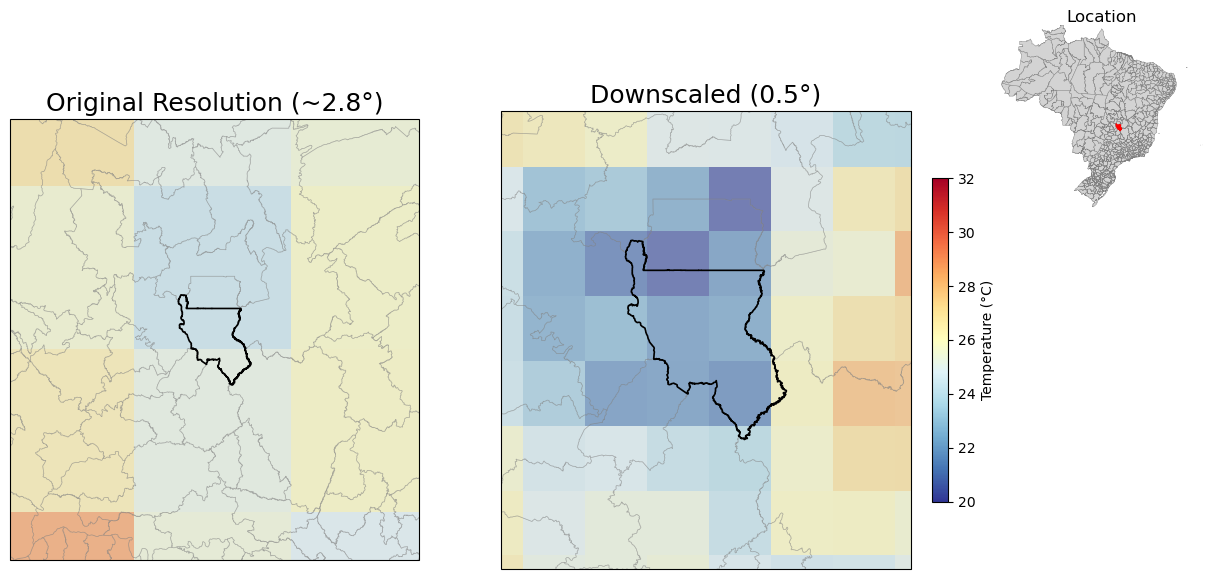

In [32]:
plot_region(region_name, shapefile, original, historical,vmin=20,vmax=32)

In [33]:
# original resolution timeseries for comparison
timeseries_original = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, original, times, time_period, rgi=region_name, pop_density=pop_density_original_resolution) for i in time_indices]
}, index=time_period)

# historical timeseries
timeseries_historical = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, historical, times, time_period,rgi=region_name) for i in time_indices]
}, index=time_period)

# natural timeseries
timeseries_natural = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, natural, times, time_period, rgi=region_name) for i in time_indices]
}, index=time_period)

# observational timeseries for comparison
timeseries_observations = pd.DataFrame({
    'population_weighted_mean' : [process_time_step(i, observations, times, time_period,rgi=region_name) for i in time_indices]
}, index=time_period)

# note: this will take a couple of minutes to run!


/Users/al18709/Documents/coding_tutorials/attribution_tutorial/timeseries_functions.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


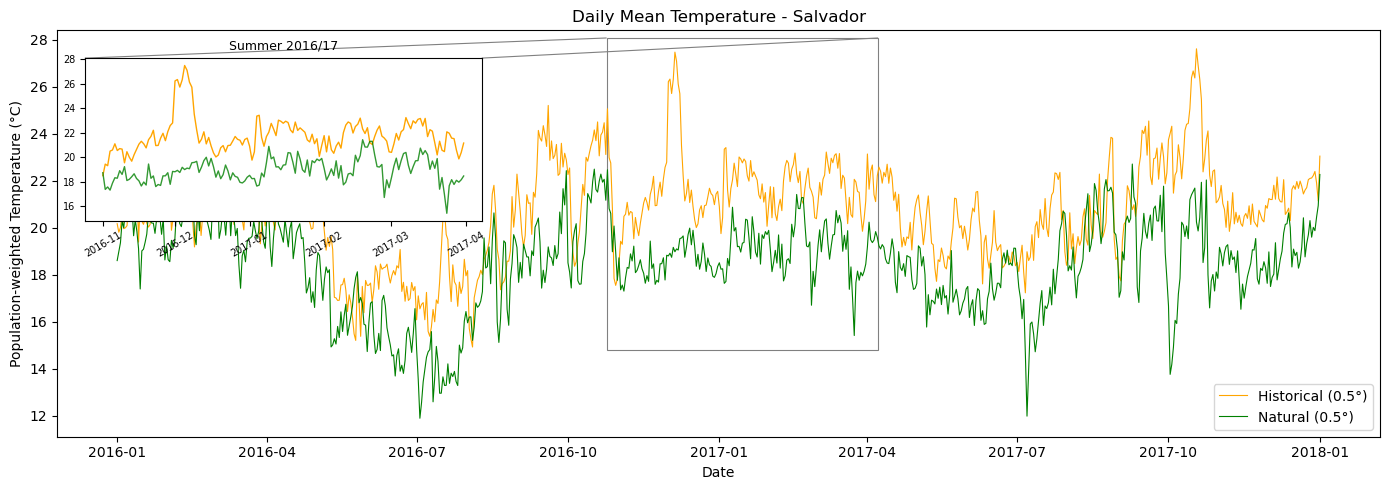

In [21]:
plot_timeseries(timeseries_historical, timeseries_natural)

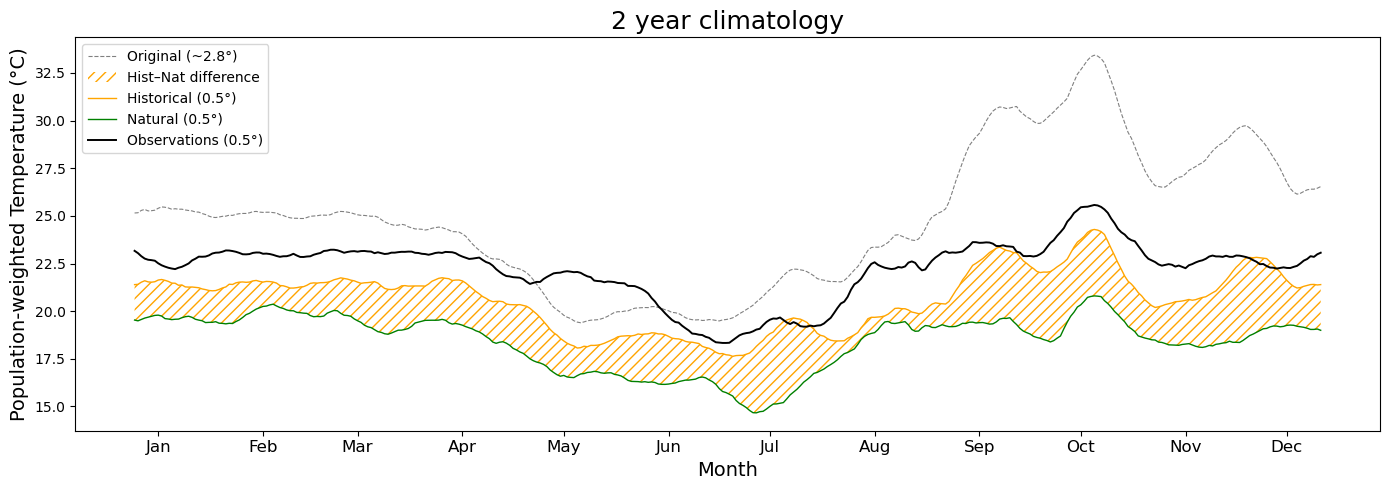

In [34]:
plot_climatology(
    timeseries_historical,
    timeseries_natural,
    timeseries_observations,
    timeseries_original=timeseries_original,
    title='2 year climatology'
)

In [35]:
# formative questions to think about